# Exploratory Data Analysis (EDA)

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *

In [2]:
spark = (
    SparkSession.builder
    .appName("BusServiceReliability")
    .master("local[*]")
    .getOrCreate()
)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/08/01 22:29:01 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/08/01 22:29:02 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/08/01 22:29:02 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
26/08/01 22:29:02 WARN Utils: Service 'SparkUI' could not bind on port 4042. Attempting port 4043.


In [3]:
df = spark.read.parquet("../outputs/cleaned_timetable_parquet")

In [4]:
df.show(5, truncate=False)

+-------------------+--------------------------------------------------------------------------------------------------------+---------+-------------------+------------------+---------------+----------+--------------------------------------------------+-------------+----------+
|creation_time      |filename                                                                                                |line_name|modified_time      |number_of_journeys|number_of_stops|operator  |route_description                                 |service_code |route_size|
+-------------------+--------------------------------------------------------------------------------------------------------+---------+-------------------+------------------+---------------+----------+--------------------------------------------------+-------------+----------+
|2022-08-19 12:05:39|X2-None--SCMY-CZ-2026-03-29-Chester_July_2026_(SchOut)__SCMY_PC1033334_224_20260719-BODS_V1_1.xml       |2        |2026-07-02 13:55:43|141    

## Dataset Summary

In [5]:
print("Number of rows:", df.count())
print("Number of columns:", len(df.columns))

Number of rows: 123
Number of columns: 10


In [6]:
df.describe().show()

26/08/01 22:30:07 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
[Stage 5:>                                                        (0 + 12) / 12]

+-------+--------------------+-----------------+------------------+------------------+----------+--------------------+-------------+----------+
|summary|            filename|        line_name|number_of_journeys|   number_of_stops|  operator|   route_description| service_code|route_size|
+-------+--------------------+-----------------+------------------+------------------+----------+--------------------+-------------+----------+
|  count|                 123|              123|               123|               123|       123|                 123|          123|       123|
|   mean|                NULL|512.7017543859649| 55.82113821138211|  62.9349593495935|      NULL|                NULL|         NULL|      NULL|
| stddev|                NULL| 312.188731487367|110.08044990438981|49.090371637402924|      NULL|                NULL|         NULL|      NULL|
|    min|10A-None--SCMY-GM...|              100|                 1|                 7|Stagecoach|Birkenhead Bus St...|PC1033334:106|    

## Route Size Distribution

In [7]:
df.groupBy("route_size").count().orderBy("route_size").show()

+----------+-----+
|route_size|count|
+----------+-----+
|      Long|   16|
|    Medium|   44|
|     Short|   63|
+----------+-----+



## Top 10 Routes with the Most Stops

In [8]:
from pyspark.sql.functions import desc

df.select(
    "line_name",
    "route_description",
    "number_of_stops"
).orderBy(desc("number_of_stops")).show(10, truncate=False)

+---------+---------------------------------------------------+---------------+
|line_name|route_description                                  |number_of_stops|
+---------+---------------------------------------------------+---------------+
|38       |Eastham Ferry - West Kirby                         |269            |
|217      |Tower Hill - Huyton                                |231            |
|2        |CZ Helsby High School                              |215            |
|16       |Moreton Cross - Eastham Rake Railway Station       |204            |
|X1       |Chester Railway Station - Liverpool via Zoo        |192            |
|84       |Chester Interchange, Stand L - Crewe Bus Station, 5|186            |
|41       |Mill Park - Woodchurch                             |177            |
|774      |Merseytravel Schools                               |151            |
|14       |Liverpool - Tower Hill                             |150            |
|603      |RF Wirral Schools            

## Top 10 Routes with the Highest Number of Journeys

In [9]:
df.select(
    "line_name",
    "route_description",
    "number_of_journeys"
).orderBy(desc("number_of_journeys")).show(10, truncate=False)

+---------+-------------------------------------------+------------------+
|line_name|route_description                          |number_of_journeys|
+---------+-------------------------------------------+------------------+
|20       |Paradise St - Towerhill                    |574               |
|82       |Paradise St - Garston                      |448               |
|86       |Liverpool ONE - South Parkway              |403               |
|17       |Liverpool - Aintree Hosp                   |382               |
|14       |Liverpool - Tower Hill                     |338               |
|5        |CZ Aldford Works P2                        |338               |
|19       |Liverpool - Kirkby                         |336               |
|41       |Mill Park - Woodchurch                     |291               |
|X1       |Chester Railway Station - Liverpool via Zoo|286               |
|10A      |Liverpool - St Helens                      |275               |
+---------+--------------

## Operator Distribution

In [11]:
df.groupBy("operator").count().show(truncate=False)

+----------+-----+
|operator  |count|
+----------+-----+
|Stagecoach|123  |
+----------+-----+



## Route Size Distribution Visualization

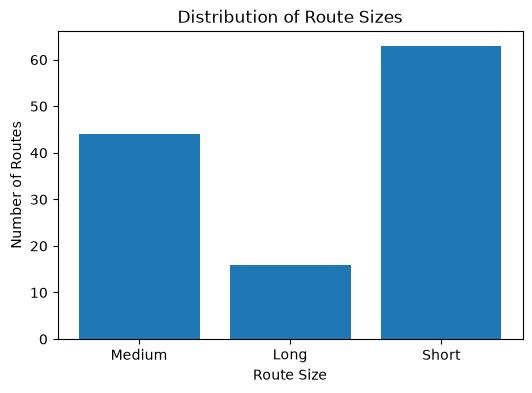

In [12]:
route_counts = df.groupBy("route_size").count().toPandas()

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(route_counts["route_size"], route_counts["count"])
plt.title("Distribution of Route Sizes")
plt.xlabel("Route Size")
plt.ylabel("Number of Routes")
plt.show()

## Number of Stops Distribution

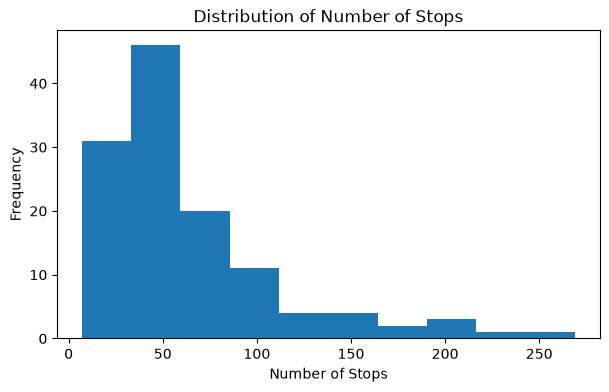

In [13]:
stops = df.select("number_of_stops").toPandas()

import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.hist(stops["number_of_stops"], bins=10)
plt.title("Distribution of Number of Stops")
plt.xlabel("Number of Stops")
plt.ylabel("Frequency")
plt.show()

## Number of Journeys Distribution

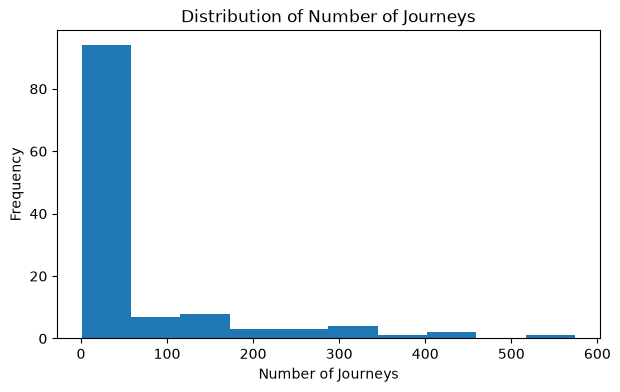

In [14]:
journeys = df.select("number_of_journeys").toPandas()

plt.figure(figsize=(7,4))
plt.hist(journeys["number_of_journeys"], bins=10)
plt.title("Distribution of Number of Journeys")
plt.xlabel("Number of Journeys")
plt.ylabel("Frequency")
plt.show()

## Relationship Between Stops and Journeys

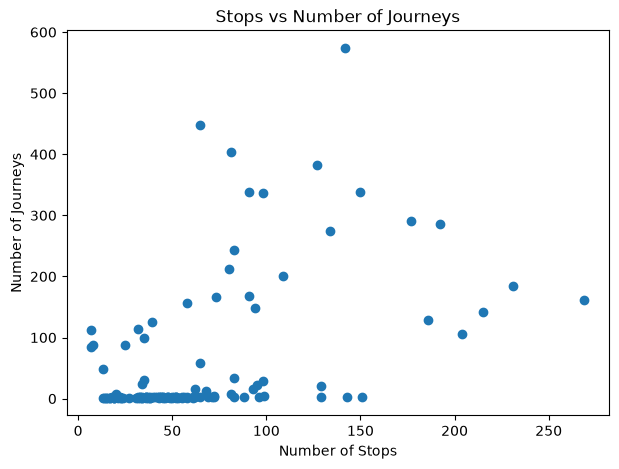

In [15]:
plot_df = df.select(
    "number_of_stops",
    "number_of_journeys"
).toPandas()

plt.figure(figsize=(7,5))
plt.scatter(
    plot_df["number_of_stops"],
    plot_df["number_of_journeys"]
)
plt.title("Stops vs Number of Journeys")
plt.xlabel("Number of Stops")
plt.ylabel("Number of Journeys")
plt.show()

# Summary

The exploratory data analysis identified the overall characteristics of the bus timetable dataset. Route sizes, numbers of stops, and journey frequencies were analyzed using summary statistics and visualizations. The analysis showed variations in route lengths and service frequencies, providing useful insights that will support the development of the predictive model in the next stage.